<a href="https://colab.research.google.com/github/nmwiley808/csci198-Music-Intelligence-with-Deep-Learning-Senior-Project/blob/main/notebooks/03_CNN_GTZAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 – CNN Baseline on GTZAN (Timed Training)

## Description

This notebook trains an improved Convolutional Neural Network (CNN)
on GTZAN log-mel spectrogram features.

Pipeline:
1. Detect project path
2. Build feature cache (if missing)
3. Normalize input features
4. Train CNN with mini-batching
5. Track validation accuracy
6. Measure training runtime

Training time is recorded per epoch and overall.

In [16]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import librosa
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time

#  Hard-set correct project path
PROJECT_PATH = "/content/drive/MyDrive/csci198/csci198-Music-Intelligence-with-Deep-Learning-Senior-Project"

if not os.path.exists(PROJECT_PATH):
    raise FileNotFoundError(f"Project path does not exist: {PROJECT_PATH}")

os.chdir(PROJECT_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Working directory:", os.getcwd())
print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/csci198/csci198-Music-Intelligence-with-Deep-Learning-Senior-Project
Device: cuda


In [17]:
# Parameters
TARGET_SR = 22050
DURATION = 30
SAMPLES_PER_TRACK = TARGET_SR * DURATION
N_MELS = 128
BATCH_SIZE = 32
EPOCHS = 30

In [18]:
# Cache Paths
os.makedirs("data/processed", exist_ok=True)

X_PATH = "data/processed/X_gtzan.npy"
Y_PATH = "data/processed/Y_gtzan.npy"
CLASS_PATH = "data/processed/label_classes_gtzan.npy"
MODEL_PATH = "data/processed/cnn_gtzan_best.pth"

In [19]:
# Build Cache If Missing
if not os.path.exists(X_PATH):

    print("Building GTZAN feature cache...")

    def load_audio(file_path):
        try:
            y, sr = librosa.load(file_path, sr=TARGET_SR)
            if len(y) > SAMPLES_PER_TRACK:
                y = y[:SAMPLES_PER_TRACK]
            else:
                y = np.pad(y, (0, SAMPLES_PER_TRACK - len(y)))
            return y
        except Exception as e:
            print(f"Warning: Could not load {file_path}. Skipping. Error: {e}")
            return None

    def extract_log_mel(y):
        mel = librosa.feature.melspectrogram(
            y=y,
            sr=TARGET_SR,
            n_mels=N_MELS
        )
        return librosa.power_to_db(mel, ref=np.max)

    gtzan_root = "data/raw/gtzan"

    X = []
    labels = []

    for root, dirs, files in os.walk(gtzan_root):
        for file in tqdm(files):
            if file.endswith(".wav"):
                label = os.path.basename(root)
                file_path = os.path.join(root, file)

                y_audio = load_audio(file_path)
                if y_audio is not None:  # Only process if audio loaded successfully
                    log_mel = extract_log_mel(y_audio)

                    X.append(log_mel)
                    labels.append(label)

    X = np.array(X)
    le = LabelEncoder()
    y = le.fit_transform(labels)

    np.save(X_PATH, X)
    np.save(Y_PATH, y)

    print("Cache saved.")
else:
    print("Cache already exists.")

Cache already exists.


In [20]:
# Load & Normalize Data
X = np.load(X_PATH)
Y = np.load(Y_PATH)

mean = np.mean(X)
std = np.std(X)
X = (X - mean) / (std + 1e-8)

print("Data normalized.")
print("X shape:", X.shape)

Data normalized.
X shape: (999, 128, 1292)


In [21]:
# Train/Test Split + DataLoader
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train = torch.tensor(X_train).unsqueeze(1).float()
X_test = torch.tensor(X_test).unsqueeze(1).float()
y_train = torch.tensor(y_train)
y_test = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

In [22]:
# CNN Architecture
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

In [23]:
# Training Loop w/ Timer
model = CNN(num_classes=len(np.unique(y))).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

best_accuracy = 0
training_start_time = time.time()

for epoch in range(EPOCHS):

    epoch_start = time.time()
    model.train()
    total_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        torch.save(model.state_dict(), MODEL_PATH)


    epoch_time = time.time() - epoch_start

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Loss: {total_loss/len(train_loader):.4f} | "
          f"Val Acc: {accuracy:.4f} | "
          f"Epoch Time: {epoch_time:.2f}s")

total_training_time = time.time() - training_start_time

print("\nBest Validation Accuracy:", best_accuracy)
print(f"Total Training Time: {total_training_time:.2f} seconds")

Epoch 1/30 | Loss: 1.9419 | Val Acc: 0.2250 | Epoch Time: 6.49s
Epoch 2/30 | Loss: 1.6548 | Val Acc: 0.4750 | Epoch Time: 6.50s
Epoch 3/30 | Loss: 1.5412 | Val Acc: 0.3900 | Epoch Time: 6.49s
Epoch 4/30 | Loss: 1.4436 | Val Acc: 0.2650 | Epoch Time: 6.52s
Epoch 5/30 | Loss: 1.4032 | Val Acc: 0.3700 | Epoch Time: 6.53s
Epoch 6/30 | Loss: 1.2992 | Val Acc: 0.5150 | Epoch Time: 6.58s
Epoch 7/30 | Loss: 1.2566 | Val Acc: 0.4650 | Epoch Time: 6.70s
Epoch 8/30 | Loss: 1.1793 | Val Acc: 0.4500 | Epoch Time: 6.59s
Epoch 9/30 | Loss: 1.1424 | Val Acc: 0.2550 | Epoch Time: 6.63s
Epoch 10/30 | Loss: 1.0379 | Val Acc: 0.6350 | Epoch Time: 6.57s
Epoch 11/30 | Loss: 0.9242 | Val Acc: 0.6550 | Epoch Time: 6.55s
Epoch 12/30 | Loss: 0.8765 | Val Acc: 0.5600 | Epoch Time: 6.51s
Epoch 13/30 | Loss: 0.8927 | Val Acc: 0.5400 | Epoch Time: 6.52s
Epoch 14/30 | Loss: 0.8620 | Val Acc: 0.5750 | Epoch Time: 6.49s
Epoch 15/30 | Loss: 0.8003 | Val Acc: 0.5850 | Epoch Time: 6.52s
Epoch 16/30 | Loss: 0.8381 | Val A

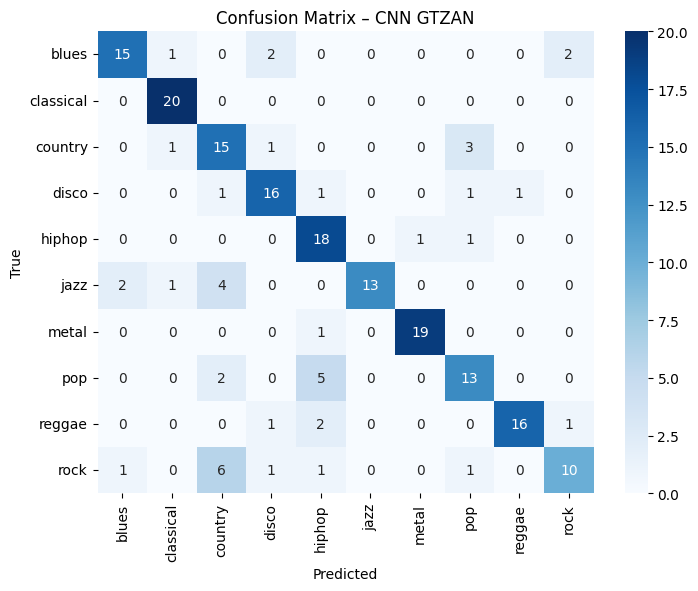

In [25]:
# Load Best Model & Confusion Matrix
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

# Define class_names for plotting the confusion matrix
# Assuming alphabetical order of GTZAN genres as typically encoded by LabelEncoder
class_names = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device);
        outputs = model(inputs);
        _, predicted = torch.max(outputs, 1);

        all_preds.extend(predicted.cpu().numpy());
        all_labels.extend(labels.cpu().numpy());

cm = confusion_matrix(all_labels, all_preds);

plt.figure(figsize=(8,6));
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names);
plt.title("Confusion Matrix – CNN GTZAN");
plt.xlabel("Predicted");
plt.ylabel("True");
plt.show();

In [26]:
# Per-Class Accuracy
class_accuracy = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_accuracy):
    print(f"{class_names[i]} Accuracy: {acc:.2f}")

blues Accuracy: 0.75
classical Accuracy: 1.00
country Accuracy: 0.75
disco Accuracy: 0.80
hiphop Accuracy: 0.90
jazz Accuracy: 0.65
metal Accuracy: 0.95
pop Accuracy: 0.65
reggae Accuracy: 0.80
rock Accuracy: 0.50
